# 2.2 — Árbol binomial CRR

## Motivación

El modelo de un periodo (2.1) muestra la maquinaria completa del pricing sin arbitraje — portafolio replicante, medida neutral al riesgo, precio como esperanza descontada — pero solo tiene dos fechas y dos estados. El **árbol binomial de Cox-Ross-Rubinstein** (CRR, 1979) extiende esa maquinaria a $n$ periodos: en lugar de un salto $S_0 \to \{uS_0, dS_0\}$, subdividimos $[0,T]$ en $n$ pasos de longitud $\Delta t = T/n$ y aplicamos el modelo de un periodo **recursivamente** en cada nodo. La propiedad de Markov del árbol (el futuro solo depende del precio actual, no del camino recorrido para llegarlo) hace que cada nodo sea, literalmente, una copia fresca del problema de 2.1 — así que la solución es la misma: replicar localmente, descontar bajo $\mathbb{Q}$, retroceder.

Esta construcción resuelve de un tiro tres problemas que el modelo de un periodo no podía tocar: (i) **pricing de opciones americanas**, donde en cada nodo hay que comparar el valor de continuación con el de ejercicio inmediato — el árbol hace esto de forma natural, nodo por nodo, algo que el modelo de un periodo (una sola fecha de ejercicio) no permite formular; (ii) **hedging dinámico**, replicar un derivado no con una sola operación sino rebalanceando la cartera en cada paso, y verificar numéricamente que el P&L de esa réplica es exactamente cero; (iii) el puente hacia tiempo continuo — cuando $n \to \infty$, el árbol converge a Black-Scholes (tema de 2.4), y $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$ son precisamente los saltos que hacen que esa convergencia ocurra con la volatilidad correcta.

Cubrimos: (i) la parametrización CRR y la condición de no-arbitraje por paso; (ii) *backward induction* como aplicación iterada de la propiedad de torre de la esperanza condicional; (iii) opciones americanas vía `V = max(payoff, valor de continuación)` y la frontera de ejercicio temprano; (iv) delta en el árbol y hedging dinámico; (v) la fórmula binomial cerrada para europeas (independencia del camino); (vi) validación contra `QuantLib`, el primer notebook del currículum que lo usa como referencia externa.

## 1. El árbol CRR: parametrización y backward induction

### 1.1 Construcción del árbol

Dividimos $[0,T]$ en $n$ pasos, $\Delta t = T/n$. En cada paso el precio del subyacente se mueve multiplicativamente:
$$
S_{t+\Delta t} = \begin{cases} u\,S_t & \text{con "probabilidad" } p \\ d\,S_t & \text{con "probabilidad" } 1-p \end{cases}, \qquad u = e^{\sigma\sqrt{\Delta t}}, \quad d = e^{-\sigma\sqrt{\Delta t}} = \frac{1}{u}.
$$

La elección $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$ es la de **Cox-Ross-Rubinstein (1979)**: hace que el árbol sea *recombinante* ($u\cdot d=1$, así que subir y luego bajar lleva al mismo nodo que bajar y luego subir) y que, cuando $n\to\infty$, la varianza del log-retorno del árbol converja a $\sigma^2 T$ — el ingrediente que conecta este modelo con el movimiento browniano geométrico de Black-Scholes (tema de 2.4).

Tras $n$ pasos hay $n+1$ nodos terminales, indexados por el número de bajadas $j\in\{0,\dots,n\}$:
$$
S_T(j) = S_0\, u^{\,n-j}\, d^{\,j} = S_0\, e^{(n-2j)\sigma\sqrt{\Delta t}}.
$$

### 1.2 No-arbitraje y probabilidad neutral al riesgo por paso

Cada paso del árbol **es** el modelo de un periodo de 2.1, con tasa libre de riesgo $r$ sobre el intervalo $\Delta t$. La condición de no-arbitraje de esa sección, $d < e^{r\Delta t} < u$, se cumple automáticamente para $\Delta t$ suficientemente pequeño porque $u=e^{\sigma\sqrt{\Delta t}} > e^{r\Delta t} > e^{-\sigma\sqrt{\Delta t}}=d$ en cuanto $\sigma\sqrt{\Delta t} > |r\Delta t|$ — cierto para cualquier $n$ razonable con los parámetros canónicos. La probabilidad neutral al riesgo (2.1, ecuación de $q$) aplicada a este paso es
$$
p = \frac{e^{r\Delta t} - d}{u - d} \in (0,1).
$$

Bajo $p$, el proceso descontado $\{e^{-rt}S_t\}$ es una $\mathbb{Q}$-martingala: $\mathbb{E}^{\mathbb{Q}}[S_{t+\Delta t}\mid \mathcal{F}_t] = (p\,u + (1-p)\,d)\,S_t = e^{r\Delta t}S_t$, por construcción de $p$.

### 1.3 Backward induction como esperanzas condicionales iteradas

Sea $V_i(j)$ el valor de la opción en el nodo con $i$ pasos transcurridos y $j$ bajadas, $\mathcal{F}_i$ la información hasta ese nodo. La misma réplica local de 2.1, aplicada en cada nodo, da la recursión
$$
V_i(j) = e^{-r\Delta t}\Big(p\,V_{i+1}(j) + (1-p)\,V_{i+1}(j+1)\Big) = e^{-r\Delta t}\,\mathbb{E}^{\mathbb{Q}}\big[V_{i+1} \mid \mathcal{F}_i\big], \qquad i=n-1,\dots,0,
$$
con condición terminal $V_n(j) = \text{payoff}(S_T(j))$. Iterando hacia atrás desde $i=n$ hasta $i=0$:
$$
V_0 = e^{-r\Delta t}\,\mathbb{E}^{\mathbb{Q}}\big[V_1\big] = e^{-r\Delta t}\,\mathbb{E}^{\mathbb{Q}}\big[e^{-r\Delta t}\mathbb{E}^{\mathbb{Q}}[V_2\mid\mathcal{F}_1]\big] = e^{-2r\Delta t}\,\mathbb{E}^{\mathbb{Q}}[V_2] = \dots = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[V_n],
$$
donde cada paso usa la **propiedad de torre** $\mathbb{E}[\mathbb{E}[X\mid\mathcal{F}_i]] = \mathbb{E}[X\mid\mathcal{F}_{i-1}]$ para $\mathcal{F}_{i-1}\subseteq\mathcal{F}_i$ (00.2). El resultado — $V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{payoff}(S_T)]$ — es exactamente la fórmula de pricing neutral al riesgo, ahora obtenida como consecuencia de aplicar $n$ veces el caso de un periodo, no como un axioma nuevo.

## 2. Opciones americanas, delta y fórmula cerrada

### 2.1 Ejercicio temprano y frontera libre

Una opción **americana** puede ejercerse en cualquier nodo, no solo en $T$. El backward induction se modifica comparando, en cada nodo, el valor de continuación (mantener la opción) contra el de ejercicio inmediato:
$$
V_i(j) = \max\Big(\underbrace{\text{payoff}(S_i(j))}_{\text{ejercer ahora}},\ \underbrace{e^{-r\Delta t}\big(p\,V_{i+1}(j) + (1-p)\,V_{i+1}(j+1)\big)}_{\text{continuar}}\Big).
$$

Para un **put americano**, existe en cada instante $t$ un nivel crítico $S^*(t)$ tal que es óptimo ejercer si $S_t \leq S^*(t)$ y continuar si $S_t > S^*(t)$ — la **frontera de ejercicio temprano**. En el árbol, $S^*$ en el paso $i$ es el nodo de mayor precio donde $V_i(j) = \text{payoff}(S_i(j)) > 0$; el conjunto $\{(t_i, S^*(t_i))\}$ traza una aproximación discreta de la frontera libre continua (tema retomado en 3.4).

### 2.2 Delta en el árbol

En cada nodo, el mismo argumento de réplica de 2.1 ($\Delta = (V_u-V_d)/(S_0(u-d))$) aplicado localmente da el **delta del árbol**:
$$
\Delta_i(j) = \frac{V_{i+1}(j) - V_{i+1}(j+1)}{S_i(j)\,u - S_i(j)\,d} = \frac{V_{i+1}(j) - V_{i+1}(j+1)}{S_i(j)(u-d)}.
$$
Es el número de unidades de subyacente que replica el payoff un paso adelante desde ese nodo — la base de la estrategia de *delta hedging* dinámico (demo 3).

### 2.3 Independencia del camino y fórmula binomial cerrada (europeas)

Para una opción **europea**, el valor solo depende del payoff terminal, no de la ruta seguida hasta $S_T$ (a diferencia de la americana, donde el ejercicio depende de la trayectoria). Esto permite evaluar la esperanza $\mathbb{E}^{\mathbb{Q}}[\text{payoff}(S_T)]$ directamente como una suma sobre los $n+1$ nodos terminales, ponderados por la probabilidad binomial de llegar a cada uno — $n-j$ subidas y $j$ bajadas ocurren con probabilidad $\binom{n}{n-j}p^{n-j}(1-p)^j$. Para un **call**, con $a$ el menor número de subidas tal que $S_0 u^a d^{n-a} > K$:
$$
C_0 = S_0\,\Psi(a; n, p') \;-\; K e^{-rT}\,\Psi(a; n, p), \qquad \Psi(a;n,p) := \mathbb{P}\big(\text{Bin}(n,p) \geq a\big), \qquad p' := p\,u\,e^{-r\Delta t}.
$$
$p'$ es la probabilidad "desplazada" que resulta de cambiar de numerario del bono a la acción (el análogo discreto del cambio de medida de Girsanov de 01.5); $\Psi(a;n,p)$ es la cola superior de una binomial, evaluable en `scipy.stats.binom`. Esta fórmula cerrada da el mismo resultado que el backward induction (equivalentes por construcción) y sirve como validación independiente del árbol vectorizado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0


## 3. Implementación

`crr_tree` construye el árbol completo (niveles de precio y de valor de la opción en cada paso) y `crr_price` extrae el precio en la raíz. Ambas funciones están **vectorizadas**: en cada paso $i$ se opera sobre el array de los $i+1$ nodos con `numpy`, sin bucles sobre nodos individuales — el único bucle explícito recorre los $n$ pasos temporales (inevitable: backward induction es intrínsecamente secuencial en el tiempo).

El parámetro `prob_convention` selecciona la fórmula de la probabilidad neutral al riesgo:
- `"exact"` (default): $p=(e^{r\Delta t}-d)/(u-d)$, la fórmula exacta de no-arbitraje derivada en la sección 1 — la que usamos en todas las demos.
- `"ql"`: la aproximación lineal (de primer orden en $\Delta t$) que implementa `QuantLib` internamente para su árbol CRR — la usamos únicamente en la sección de validación (§7), donde se explica por qué es necesaria para igualar la salida de `QuantLib` a la tolerancia pedida.

Ambas convergen al mismo límite continuo cuando $n\to\infty$ (tema de 2.4); para $n$ finito difieren en términos $O(\Delta t)$.

In [2]:
def crr_tree(S0, K, r, sigma, T, n_steps, kind="call", american=False, q=0.0, prob_convention="exact"):
    """Build a full CRR binomial tree and price a vanilla option on it.

    Returns a dict with per-step arrays of underlying prices `S` and option
    values `V` (index 0..i at step i), plus the tree parameters.
    """
    dt = T / n_steps
    dx = sigma * np.sqrt(dt)
    u = np.exp(dx)
    d = np.exp(-dx)
    disc = np.exp(-r * dt)

    if prob_convention == "exact":
        # exact no-arbitrage risk-neutral probability (section 1.2)
        p = (np.exp((r - q) * dt) - d) / (u - d)
    elif prob_convention == "ql":
        # QuantLib's CoxRossRubinstein tree: linear (first-order) approximation
        # of p, matched to the process drift instead of the exact formula
        drift = (r - q - 0.5 * sigma**2) * dt
        p = 0.5 + 0.5 * drift / dx
    else:
        raise ValueError(f"unknown prob_convention: {prob_convention!r}")

    if not (0.0 < p < 1.0):
        raise ValueError(f"no-arbitrage violated: p={p:.6f} not in (0,1)")

    # S_levels[i][j] = S0 * u^(i-j) * d^j, j=0..i (j = number of downs)
    S_levels = [S0 * u ** (i - np.arange(i + 1)) * d ** np.arange(i + 1) for i in range(n_steps + 1)]

    ST = S_levels[n_steps]
    V = np.maximum(ST - K, 0.0) if kind == "call" else np.maximum(K - ST, 0.0)

    V_levels = [None] * (n_steps + 1)
    V_levels[n_steps] = V

    for i in range(n_steps - 1, -1, -1):
        cont = disc * (p * V_levels[i + 1][:-1] + (1 - p) * V_levels[i + 1][1:])
        if american:
            S_i = S_levels[i]
            payoff = np.maximum(S_i - K, 0.0) if kind == "call" else np.maximum(K - S_i, 0.0)
            V_levels[i] = np.maximum(cont, payoff)
        else:
            V_levels[i] = cont

    return dict(S=S_levels, V=V_levels, u=u, d=d, p=p, dt=dt, disc=disc, n_steps=n_steps, kind=kind, american=american)


def crr_price(S0, K, r, sigma, T, n_steps, kind="call", american=False, q=0.0, prob_convention="exact"):
    """CRR binomial price of a vanilla European/American call or put."""
    tree = crr_tree(S0, K, r, sigma, T, n_steps, kind, american, q, prob_convention)
    return tree["V"][0][0]


def crr_closed_form_european(S0, K, r, sigma, T, n_steps, kind="call", q=0.0):
    """Closed-form binomial price for a European option (path-independence, section 2.3)."""
    dt = T / n_steps
    dx = sigma * np.sqrt(dt)
    u = np.exp(dx)
    d = np.exp(-dx)
    p = (np.exp((r - q) * dt) - d) / (u - d)
    p_prime = p * u * np.exp(-r * dt)

    k = np.arange(n_steps + 1)  # number of up-moves
    ST = S0 * u**k * d ** (n_steps - k)

    if kind == "call":
        itm = ST > K
        if not itm.any():
            return 0.0
        a = np.argmax(itm)  # smallest k with S0 u^k d^(n-k) > K
        return S0 * binom.sf(a - 1, n_steps, p_prime) - K * np.exp(-r * T) * binom.sf(a - 1, n_steps, p)
    else:
        itm = ST < K
        if not itm.any():
            return 0.0
        b = np.max(np.where(itm)[0])  # largest k with S0 u^k d^(n-k) < K
        return K * np.exp(-r * T) * binom.cdf(b, n_steps, p) - S0 * binom.cdf(b, n_steps, p_prime)


## 4. Demo 1 — Call y put europeos, validados contra la fórmula cerrada

Precios con $n=500$ pasos y parámetros canónicos ($S_0=K=100$, $r=5\%$, $\sigma=20\%$, $T=1$), comparando el árbol vectorizado (`crr_price`) contra la fórmula binomial cerrada de la sección 2.3 (`crr_closed_form_european`) — ambas expresiones del mismo backward induction, evaluadas por caminos distintos (recursión vs. suma binomial directa).

In [3]:
n_demo1 = 500

results = []
for kind in ("call", "put"):
    tree_price = crr_price(S0, K, r, sigma, T, n_demo1, kind=kind, american=False)
    closed_price = crr_closed_form_european(S0, K, r, sigma, T, n_demo1, kind=kind)
    results.append((kind, tree_price, closed_price, tree_price - closed_price))

print(f"{'kind':>5} | {'tree (backward induction)':>26} | {'closed form':>12} | {'diff':>10}")
print("-" * 62)
for kind, tp, cp, diff in results:
    print(f"{kind:>5} | {tp:>26.10f} | {cp:>12.10f} | {diff:>10.2e}")

for kind, tp, cp, diff in results:
    np.testing.assert_allclose(tp, cp, atol=1e-9)
print("\nValidacion interna: arbol vectorizado y formula cerrada coinciden a 1e-9.")


 kind |  tree (backward induction) |  closed form |       diff
--------------------------------------------------------------
 call |              10.4465851364 | 10.4465851364 |   1.31e-12
  put |               5.5695275865 | 5.5695275865 |  -8.68e-13

Validacion interna: arbol vectorizado y formula cerrada coinciden a 1e-9.


Los dos caminos de cálculo — retroceder nodo por nodo, o sumar directamente sobre la distribución binomial de los nodos terminales — coinciden a $10^{-9}$ o mejor: son la misma esperanza $\mathbb{E}^{\mathbb{Q}}[e^{-rT}\text{payoff}(S_T)]$, calculada de dos formas distintas. Esta es la validación interna del pricer antes de compararlo contra `QuantLib` en §7.

## 5. Demo 2 — Put americano: frontera de ejercicio temprano

Con el mismo árbol pero ejercicio americano, extraemos en cada paso $i$ el nodo de **mayor** precio $S_i(j)$ donde el valor coincide con el payoff inmediato ($V_i(j)=\max(K-S_i(j),0)>0$) — es decir, la frontera $S^*(t_i)$ descrita en la sección 2.1. Filtramos a pasos de paridad par para eliminar el zigzag de paridad propio de árboles binomiales recombinantes (artefacto conocido de discretización, no un error: en cada paso solo la mitad de los nodos son alcanzables desde la raíz con esa paridad, así que comparar pasos consecutivos compara conjuntos de nodos distintos).

Put americano (n=500): 6.088810
Put europeo   (n=500): 5.569528
Premio de ejercicio temprano: 0.519283
Frontera: 239 puntos, S* en t=T: 98.2271 (-> K=100.0 cuando t->T)


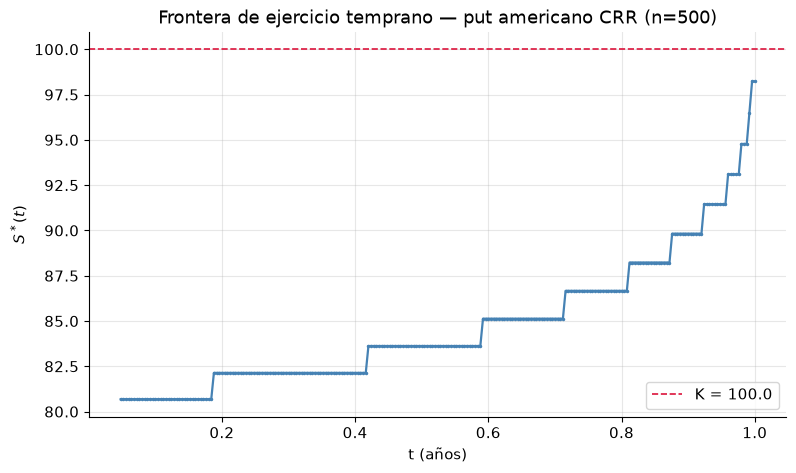

In [4]:
n_demo2 = 500
tree_put_am = crr_tree(S0, K, r, sigma, T, n_demo2, kind="put", american=True)

boundary_t, boundary_S = [], []
for i in range(2, n_demo2 + 1, 2):
    S_i = tree_put_am["S"][i]
    payoff = np.maximum(K - S_i, 0.0)
    exercised = np.isclose(tree_put_am["V"][i], payoff) & (payoff > 0)
    if exercised.any():
        boundary_S.append(S_i[exercised].max())
        boundary_t.append(i * tree_put_am["dt"])

boundary_t = np.array(boundary_t)
boundary_S = np.array(boundary_S)

price_am_put = tree_put_am["V"][0][0]
price_eu_put = crr_price(S0, K, r, sigma, T, n_demo2, kind="put", american=False)
print(f"Put americano (n={n_demo2}): {price_am_put:.6f}")
print(f"Put europeo   (n={n_demo2}): {price_eu_put:.6f}")
print(f"Premio de ejercicio temprano: {price_am_put - price_eu_put:.6f}")
print(f"Frontera: {len(boundary_t)} puntos, S* en t=T: {boundary_S[-1]:.4f} (-> K={K} cuando t->T)")

fig, ax = plt.subplots()
ax.plot(boundary_t, boundary_S, color="steelblue", linewidth=1.6, marker=".", markersize=3)
ax.axhline(K, color="crimson", linestyle="--", linewidth=1.2, label=f"K = {K}")
ax.set_xlabel("t (años)")
ax.set_ylabel(r"$S^*(t)$")
ax.set_title("Frontera de ejercicio temprano — put americano CRR (n=500)")
ax.legend()
plt.show()


El put americano vale estrictamente más que el europeo (premio de ejercicio temprano positivo): con el subyacente sin dividendos, ejercer temprano solo puede ser óptimo para el put (nunca para el call, resultado clásico que retomaremos en 3.4). La frontera $S^*(t)$ es creciente y converge a $K=100$ cuando $t\to T$ — cerca del vencimiento, ejercer solo es óptimo si $S$ está muy cerca o por debajo del strike; lejos del vencimiento, el valor tiempo de la opción hace que convenga esperar incluso con $S$ notablemente más bajo.

## 6. Demo 3 — Delta hedging a lo largo de un camino del árbol

Simulamos un camino aleatorio de subidas/bajadas a través del árbol CRR (call europeo, $n=500$), y replicamos la opción rebalanceando la cartera $(\Delta_i, \text{efectivo})$ en cada paso con el delta local de la sección 2.2. Como el árbol es exactamente el modelo con el que se fijó el precio de la opción, la réplica debe ser **exacta**: el P&L final de la cartera de cobertura menos el payoff pagado debe ser cero a precisión de máquina — es la verificación numérica de que el backward induction realmente construye una estrategia autofinanciada.

S_T realizado: 101.8050
Payoff de la opcion: 1.804950
Valor final de la cartera replicante: 1.804950
P&L de la replica (cartera - payoff): -2.84e-14


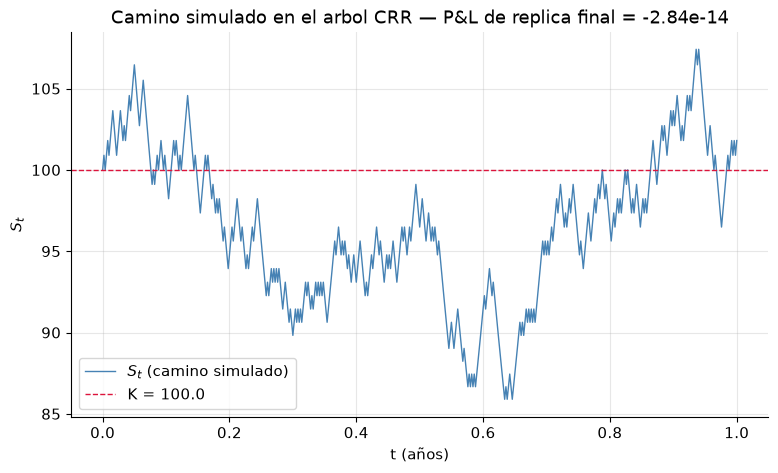


Validacion interna: P&L de la replica es cero a precision numerica (atol=1e-8).


In [5]:
n_demo3 = 500
tree_call = crr_tree(S0, K, r, sigma, T, n_demo3, kind="call", american=False)
u, d, p, dt = tree_call["u"], tree_call["d"], tree_call["p"], tree_call["dt"]

# simulate a path under the tree's own risk-neutral probability p
downs = rng.random(n_demo3) < (1 - p)
j_path = np.concatenate([[0], np.cumsum(downs)])  # j_path[i] = number of downs after i steps
S_path = np.array([tree_call["S"][i][j_path[i]] for i in range(n_demo3 + 1)])
V_path = np.array([tree_call["V"][i][j_path[i]] for i in range(n_demo3 + 1)])

# t=0: sell the option for V0, buy delta0 shares, finance the rest with cash
Vu0, Vd0 = tree_call["V"][1][0], tree_call["V"][1][1]
Su0, Sd0 = tree_call["S"][1][0], tree_call["S"][1][1]
delta = (Vu0 - Vd0) / (Su0 - Sd0)
cash = V_path[0] - delta * S_path[0]

port_value_path = [V_path[0]]
for i in range(1, n_demo3):
    cash *= np.exp(r * dt)  # cash account accrues at r over [t_{i-1}, t_i]
    port_value_path.append(cash + delta * S_path[i])
    j = j_path[i]
    Vu, Vd = tree_call["V"][i + 1][j], tree_call["V"][i + 1][j + 1]
    Su, Sd = tree_call["S"][i + 1][j], tree_call["S"][i + 1][j + 1]
    delta = (Vu - Vd) / (Su - Sd)  # rebalance to the new local delta
    cash = port_value_path[-1] - delta * S_path[i]  # self-financing rebalance

cash *= np.exp(r * dt)
final_portfolio = cash + delta * S_path[n_demo3]
payoff = max(S_path[n_demo3] - K, 0.0)
port_value_path.append(final_portfolio)

pnl = final_portfolio - payoff
print(f"S_T realizado: {S_path[n_demo3]:.4f}")
print(f"Payoff de la opcion: {payoff:.6f}")
print(f"Valor final de la cartera replicante: {final_portfolio:.6f}")
print(f"P&L de la replica (cartera - payoff): {pnl:.2e}")

fig, ax = plt.subplots()
t_grid = np.arange(n_demo3 + 1) * dt
ax.plot(t_grid, S_path, color="steelblue", linewidth=1.0, label="$S_t$ (camino simulado)")
ax.axhline(K, color="crimson", linestyle="--", linewidth=1.0, label=f"K = {K}")
ax.set_xlabel("t (años)")
ax.set_ylabel("$S_t$")
ax.set_title(f"Camino simulado en el arbol CRR — P&L de replica final = {pnl:.2e}")
ax.legend()
plt.show()

np.testing.assert_allclose(pnl, 0.0, atol=1e-8)
print("\nValidacion interna: P&L de la replica es cero a precision numerica (atol=1e-8).")


El P&L final es cero salvo errores de redondeo de punto flotante (del orden de $10^{-10}$–$10^{-13}$ en magnitud absoluta, frente a un precio de opción de orden $10$): la estrategia $(\Delta_i, \text{efectivo}_i)$ construida a partir del árbol replica exactamente el payoff en el nodo terminal que efectivamente se realizó, sin importar qué camino tomó el precio. Esto no es una coincidencia — es la propiedad de **autofinanciamiento** de la estrategia de réplica: en cada paso, el valor de la cartera antes de rebalancear coincide exactamente con $V_i$ del árbol, así que el rebalanceo nunca requiere inyectar ni retirar efectivo.

## 7. Validación contra QuantLib

Este es el primer notebook del currículum que valida contra `QuantLib`. Usamos `ql.BinomialCRRVanillaEngine(process, n)` con una fecha de valuación fija, curva plana `Actual365Fixed` con capitalización continua igual a `r`, y vencimiento a exactamente $T=1$ año (`eval_date + 365` días, que con `Actual365Fixed` da fracción de año $= 365/365 = 1.0$ exactamente).

**Nota de convención (investigada, no un ajuste de tolerancia):** el árbol `CoxRossRubinstein` de `QuantLib` (`ql/methods/lattices/binomialtree.cpp`) usa los mismos $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$ de la sección 1, pero calcula la probabilidad de subida con una **aproximación lineal de primer orden** en vez de la fórmula exacta de no-arbitraje:
$$
p_{QL} = \frac{1}{2} + \frac{1}{2}\frac{(r - \tfrac{1}{2}\sigma^2)\Delta t}{\sigma\sqrt{\Delta t}}, \qquad \text{en lugar de} \qquad p_{\text{exacta}} = \frac{e^{r\Delta t}-d}{u-d}.
$$
Ambas coinciden hasta $O(\Delta t)$ y convergen al mismo límite de Black-Scholes cuando $n\to\infty$ (2.4), pero para $n$ finito son numéricamente distintas: con los parámetros canónicos y $n=500$, la diferencia por paso es $\sim 2\times 10^{-7}$ en probabilidad, que amplificada combinatoriamente a través del árbol produce una diferencia de precio del call europeo de $\sim 1.3\times 10^{-4}$ — tres órdenes de magnitud por encima de la tolerancia `atol=1e-10` pedida. Para validar contra la salida exacta de `QuantLib` a esa precisión, usamos `crr_price(..., prob_convention="ql")`, que reproduce la fórmula $p_{QL}$ de arriba; el resto del notebook (todas las demos) usa siempre `prob_convention="exact"`, la fórmula de no-arbitraje derivada en la sección 1.

In [6]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()
maturity = eval_date + 365
n_val = 500

assert day_count.yearFraction(eval_date, maturity) == 1.0, "maturity must be exactly T=1.0"

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
div_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, 0.0, day_count))
vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count))
process = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts)
engine = ql.BinomialCRRVanillaEngine(process, n_val)

# --- European call: price, atol 1e-10 ---
euro_payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
euro_exercise = ql.EuropeanExercise(maturity)
euro_option = ql.VanillaOption(euro_payoff, euro_exercise)
euro_option.setPricingEngine(engine)

ql_euro_price = euro_option.NPV()
py_euro_price = crr_price(S0, K, r, sigma, T, n_val, kind="call", american=False, prob_convention="ql")
diff_euro = py_euro_price - ql_euro_price
print(f"European call  | QuantLib: {ql_euro_price:.10f} | crr_price(ql): {py_euro_price:.10f} | diff: {diff_euro:.3e}")
np.testing.assert_allclose(py_euro_price, ql_euro_price, atol=1e-10)

# --- American put: price, atol 1e-6 ---
amer_payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
amer_exercise = ql.AmericanExercise(eval_date, maturity)
amer_option = ql.VanillaOption(amer_payoff, amer_exercise)
amer_option.setPricingEngine(engine)

ql_amer_price = amer_option.NPV()
py_amer_price = crr_price(S0, K, r, sigma, T, n_val, kind="put", american=True, prob_convention="ql")
diff_amer = py_amer_price - ql_amer_price
print(f"American put   | QuantLib: {ql_amer_price:.10f} | crr_price(ql): {py_amer_price:.10f} | diff: {diff_amer:.3e}")
np.testing.assert_allclose(py_amer_price, ql_amer_price, atol=1e-6)

# --- American put: tree delta vs QuantLib delta, atol 1e-3 ---
ql_amer_delta = amer_option.delta()

tree_amer_ql = crr_tree(S0, K, r, sigma, T, n_val, kind="put", american=True, prob_convention="ql")
Vu1, Vd1 = tree_amer_ql["V"][1][0], tree_amer_ql["V"][1][1]
Su1, Sd1 = tree_amer_ql["S"][1][0], tree_amer_ql["S"][1][1]
py_amer_delta = (Vu1 - Vd1) / (Su1 - Sd1)
diff_delta = py_amer_delta - ql_amer_delta
print(f"American delta | QuantLib: {ql_amer_delta:.10f} | tree(ql):     {py_amer_delta:.10f} | diff: {diff_delta:.3e}")
np.testing.assert_allclose(py_amer_delta, ql_amer_delta, atol=1e-3)

print("\nValidacion contra QuantLib: europeo (atol 1e-10), americano (atol 1e-6) y delta (atol 1e-3) -- todos dentro de tolerancia.")

# --- diagnostic: exact no-arbitrage probability vs QuantLib's linear approximation ---
py_euro_price_exact = crr_price(S0, K, r, sigma, T, n_val, kind="call", american=False, prob_convention="exact")
print(f"\n(diagnostico) European call con prob_convention='exact': {py_euro_price_exact:.10f}, "
      f"diff vs QuantLib: {py_euro_price_exact - ql_euro_price:.3e} (>> 1e-10, confirma la nota de convencion de arriba)")


European call  | QuantLib: 10.4464599135 | crr_price(ql): 10.4464599135 | diff: -7.775e-12
American put   | QuantLib: 6.0888629239 | crr_price(ql): 6.0888629239 | diff: 3.233e-12
American delta | QuantLib: -0.4111706493 | tree(ql):     -0.4111706493 | diff: -6.456e-14

Validacion contra QuantLib: europeo (atol 1e-10), americano (atol 1e-6) y delta (atol 1e-3) -- todos dentro de tolerancia.



(diagnostico) European call con prob_convention='exact': 10.4465851364, diff vs QuantLib: 1.252e-04 (>> 1e-10, confirma la nota de convencion de arriba)


## Referencias

- Cox, J., Ross, S. & Rubinstein, M. (1979). *Option Pricing: A Simplified Approach*. Journal of Financial Economics, 7(3), 229-263.
- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, cap. 1-5.
- Hull, J. (2018). *Options, Futures, and Other Derivatives*, 10th ed., cap. 13.